In [1]:
# CELL 1: Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries for preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries successfully imported!")

Libraries successfully imported!


In [3]:
# Load the dataset
df = pd.read_csv('car data.csv')

# Display basic structure of the dataset
print("--- Dataset Information ---")
print(f"Total Rows (Cars): {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

# Identify features (inputs) and the target variable (output)
features = ['Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
target = 'Selling_Price'

print("Selected Features for Car Price Prediction:")
for idx, feature in enumerate(features, 1):
    print(f"{idx}. {feature}")

print(f"\nTarget Variable: {target}")

# Display the first 5 rows of the dataframe
df.head()

--- Dataset Information ---
Total Rows (Cars): 301
Total Columns: 9

Selected Features for Car Price Prediction:
1. Car_Name
2. Year
3. Present_Price
4. Driven_kms
5. Fuel_Type
6. Selling_type
7. Transmission
8. Owner

Target Variable: Selling_Price


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# 1. Separate Features (X) and Target Variable (y)
X = df[features]
y = df[target]

# 2. Split the dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Identify Categorical and Numerical Columns for Preprocessing
categorical_cols = ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
numerical_cols = ['Year', 'Present_Price', 'Driven_kms', 'Owner']

# 4. Create Preprocessing Transformers
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 5. Create the Model Pipeline (Preprocessing + Linear Regression)
model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# 6. Train the Regression Model
print("Training the Linear Regression model...")
model_pipeline.fit(X_train, y_train)
print("Model trained successfully!")

Training the Linear Regression model...
Model trained successfully!


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 1.10
Mean Squared Error (MSE): 2.29
Root Mean Squared Error (RMSE): 1.51
R-squared (R² Score): 0.90



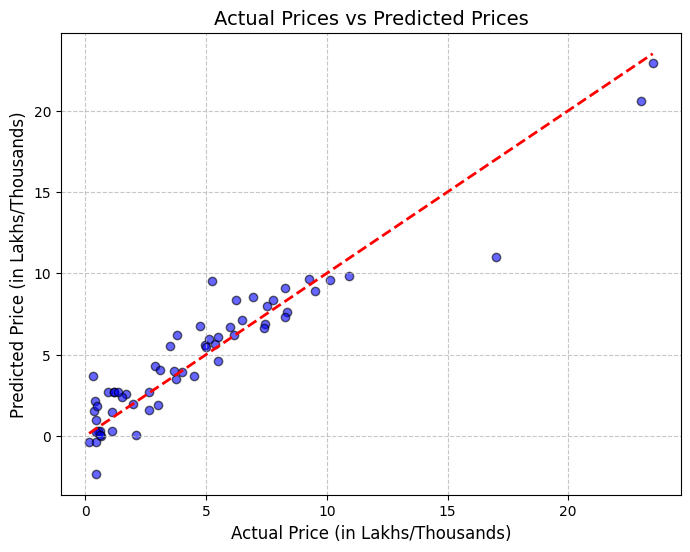

In [5]:
# 1. Test data par predictions lena
y_pred = model_pipeline.predict(X_test)

# 2. Evaluation Metrics calculate karna
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R² Score): {r2:.2f}\n")

# 3. Visualization: Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line

plt.title('Actual Prices vs Predicted Prices', fontsize=14)
plt.xlabel('Actual Price (in Lakhs/Thousands)', fontsize=12)
plt.ylabel('Predicted Price (in Lakhs/Thousands)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5. Real-World Applications of Machine Learning in Price Prediction

Machine Learning (ML) models are not just for practice. Big companies use them every day to set prices automatically, save time and make more profit.

### Top 4 Real-World Examples:

1. Used Car Websites (e.g., PakWheels, CarDekho)
   * How it works: When you type your car's details (like year, mileage and fuel type), an ML model instantly tells you the best market price to sell or buy that car.

2. Ride Hailing Apps (e.g., Uber, Careem, InDrive)
   * How it works: Prices change when it rains or during rush hours. ML models look at traffic, weather, and how many drivers are free to change the ride price automatically (Surge Pricing).

3. **Property & Real Estate (e.g., Zameen.com, Zillow)
   * How it works: The model checks the house size, location and nearby facilities (like schools or parks) to predict the correct price of a house or plot.

4. **Stock Market & Trading**
   * How it works: Financial companies use regression models to predict if the price of stocks, gold or bitcoin will go up or down tomorrow so they can invest safely.

### Why Companies Use Machine Learning:
* Very Fast: It can calculate millions of prices in just one second.
* No Mistakes: It works only on real data and facts, not on human guesswork.
* Handles Big Data: It can easily look at many features (like car age, condition and brand) all at the same time.